In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Gametocyte picture vs infectiousness picture

In [3]:
import math


def expcdf(x, lmbda=1):
    if x < 0:
        return 0
    else:
        return 1 - math.exp(-lmbda * x)
    
def get_inv_micro_liters_blood(age_years):
    age_effective = min(age_years, 20)
    return 1e-6/(0.225*age_effective + 0.5)

def infectiousness_from_gametocytes(n_gametocytes, age_years):
    inv_microliters_blood = get_inv_micro_liters_blood(age_years)
    microliters_per_bloodmeal = 1
    base_gametocyte_mosquito_survival = 0.002011099
    fever_effect = 0
    return expcdf(n_gametocytes * inv_microliters_blood * microliters_per_bloodmeal * base_gametocyte_mosquito_survival * (1.0 - fever_effect))

In [23]:
from functools import partial

x = partial(infectiousness_from_gametocytes, age_years=20)

In [24]:
y = np.vectorize(x)

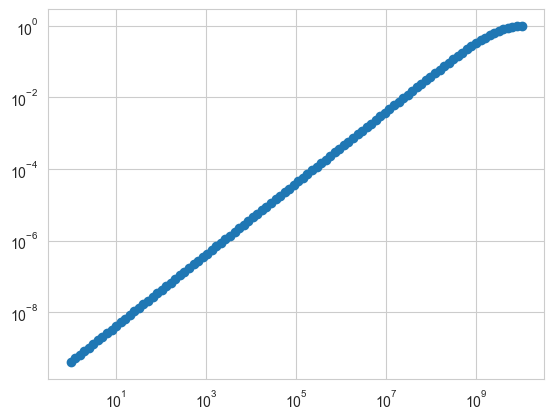

In [25]:
n_gametocytes = np.logspace(start=0, stop=10, num=100)
# plt.scatter(n_gametocytes, infectiousness_from_gametocytes(n_gametocytes, age_years=10))
plt.scatter(n_gametocytes, y(n_gametocytes))
plt.xscale('log')
plt.yscale("log")

In [26]:
def fake_infectiousness(n_gametocytes):
    total_blood_volume = 5000000
    gametocyte_density = n_gametocytes/total_blood_volume
    prob_zero_picked_up = np.exp(-gametocyte_density)
    return 1-prob_zero_picked_up

In [29]:
print(fake_infectiousness(100))
print(infectiousness_from_gametocytes(100, 20))

1.999980000133572e-05
4.022197919173465e-08


Text(0.5, 0, 'Gametocyte density')

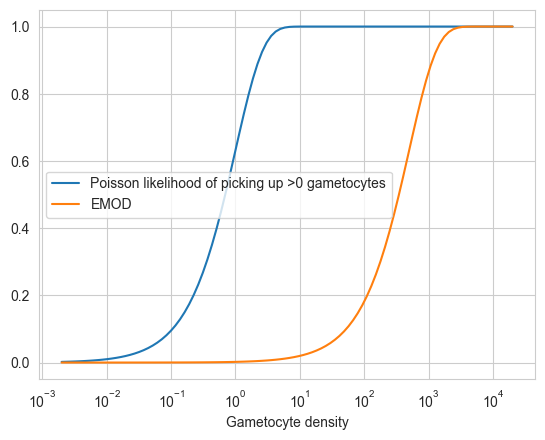

In [42]:
n_gametocytes = np.logspace(start=4, stop=11, num=100)

yy = np.vectorize(fake_infectiousness)
plt.plot(n_gametocytes/5000000, yy(n_gametocytes), label="Poisson likelihood of picking up >0 gametocytes")
plt.plot(n_gametocytes/5000000, y(n_gametocytes), label="EMOD")
plt.xscale('log')
plt.legend()
plt.xlabel("Gametocyte density")

In [35]:
10**7/5000000

2.0

Interesting that the Poisson model looks like the EMOD model but shifted over. What threshold of gametocyte pickup would be needed to make the curves roughly overlap?

In [53]:
gametocyte_density = 1
minimum_number_to_pick_up = 5
print([np.exp(-gametocyte_density)*gametocyte_density**i/math.factorial(i) for i in range(minimum_number_to_pick_up)])
print(1-np.sum([np.exp(-gametocyte_density)*gametocyte_density**i/math.factorial(i) for i in range(minimum_number_to_pick_up)]))

[0.36787944117144233, 0.36787944117144233, 0.18393972058572117, 0.06131324019524039, 0.015328310048810098]
0.00365984682734366


In [60]:
from scipy.stats import poisson

def fake_infectiousness_2(n_gametocytes, minimum_number_to_pick_up=1):
    total_blood_volume = 5000000
    gametocyte_density = n_gametocytes/total_blood_volume
    # prob_less_than_threshold_picked_up = np.sum([np.exp(-gametocyte_density)*gametocyte_density**i/math.factorial(i) for i in range(minimum_number_to_pick_up)])
    prob_less_than_threshold_picked_up = poisson.cdf(minimum_number_to_pick_up-1, gametocyte_density)
    return 1-prob_less_than_threshold_picked_up

Text(0.5, 0, 'Gametocyte density')

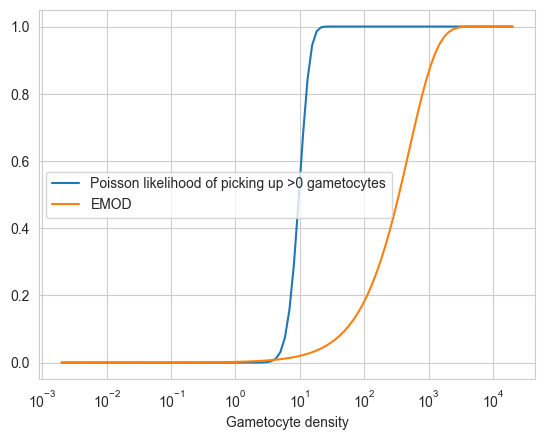

In [68]:
n_gametocytes = np.logspace(start=4, stop=11, num=100)

yy = np.vectorize(partial(fake_infectiousness_2, minimum_number_to_pick_up=10))
plt.plot(n_gametocytes/5000000, yy(n_gametocytes), label="Poisson likelihood of picking up >0 gametocytes")
plt.plot(n_gametocytes/5000000, y(n_gametocytes), label="EMOD")
plt.xscale('log')
plt.legend()
plt.xlabel("Gametocyte density")

Text(0.5, 0, 'Gametocyte density')

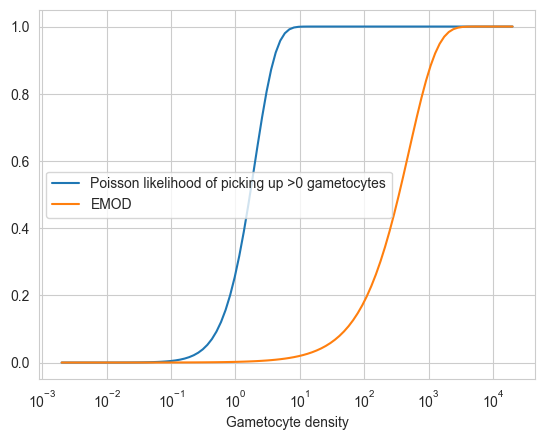

In [66]:
n_gametocytes = np.logspace(start=4, stop=11, num=100)

yy = np.vectorize(partial(fake_infectiousness_2, minimum_number_to_pick_up=2))
plt.plot(n_gametocytes/5000000, yy(n_gametocytes), label="Poisson likelihood of picking up >0 gametocytes")
plt.plot(n_gametocytes/5000000, y(n_gametocytes), label="EMOD")
plt.xscale('log')
plt.legend()
plt.xlabel("Gametocyte density")